# E-COMMERCE CUSTOMER BEHAVIOR ANALYSIS PROJECT

## 1. IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")


## 2 Loading data

In [2]:
data_folder = Path('../data')
csv_path = data_folder / 'ecommerce_customers.csv'

# Read the dataset
df = pd.read_csv(csv_path)

print(" Dataset Loaded Successfully!")

 Dataset Loaded Successfully!


## 3.Data Profiling

In [3]:
# Print first 5 row
df.head()



,customer_id,age,gender,country,device_type,session_duration,pages_visited,products_viewed,cart_additions,purchases,total_spent,last_purchase_days,membership_status,discount_used,churn
0,1,56,Male,Nigeria,Desktop,104,30,13,4,5,1455.74,34,Premium,No,0
1,2,46,Female,Kenya,Mobile,75,37,13,12,1,1201.37,242,Basic,No,1
2,3,32,Female,Nigeria,Tablet,48,25,17,10,3,1075.58,113,Premium,No,0
3,4,60,Female,Nigeria,Desktop,32,48,17,3,6,2061.61,318,Premium,Yes,0
4,5,25,Male,Nigeria,Desktop,57,27,5,6,7,3523.12,23,Basic,Yes,0


In [4]:
df.columns

Index(['customer_id', 'age', 'gender', 'country', 'device_type',
       'session_duration', 'pages_visited', 'products_viewed',
       'cart_additions', 'purchases', 'total_spent', 'last_purchase_days',
       'membership_status', 'discount_used', 'churn'],
      dtype='object')

In [5]:
print("\nDataset Shape:")
print(df.shape)



Dataset Shape:
(1000, 15)


In [6]:
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         1000 non-null   int64  
 1   age                 1000 non-null   int64  
 2   gender              1000 non-null   object 
 3   country             1000 non-null   object 
 4   device_type         1000 non-null   object 
 5   session_duration    1000 non-null   int64  
 6   pages_visited       1000 non-null   int64  
 7   products_viewed     1000 non-null   int64  
 8   cart_additions      1000 non-null   int64  
 9   purchases           1000 non-null   int64  
 10  total_spent         1000 non-null   float64
 11  last_purchase_days  1000 non-null   int64  
 12  membership_status   1000 non-null   object 
 13  discount_used       1000 non-null   object 
 14  churn               1000 non-null   int64  
dtypes: float64(1), int64(9), object(5)
memory

In [7]:
print("\nSummary Statistics:")
df.describe()


Summary Statistics:


,customer_id,age,session_duration,pages_visited,products_viewed,cart_additions,purchases,total_spent,last_purchase_days,churn
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,500.500000,40.986000,60.312000,25.159000,15.266000,7.133000,4.497000,2493.963170,184.57500,0.157000
std,288.819436,13.497852,34.307458,14.187424,8.191358,4.228616,2.932677,1442.669802,106.15543,0.363983
min,1.000000,18.000000,1.000000,1.000000,1.000000,0.000000,0.000000,29.550000,1.00000,0.000000
25%,250.750000,29.000000,30.000000,13.000000,8.000000,3.000000,2.000000,1229.532500,92.00000,0.000000
50%,500.500000,42.000000,59.000000,25.000000,15.000000,7.000000,5.000000,2503.970000,186.00000,0.000000
75%,750.250000,52.000000,91.000000,38.000000,22.000000,11.000000,7.000000,3729.765000,280.25000,0.000000
max,1000.000000,64.000000,119.000000,49.000000,29.000000,14.000000,9.000000,4997.310000,364.00000,1.000000


##  4.Data Cleaning

In [8]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
customer_id           0
age                   0
gender                0
country               0
device_type           0
session_duration      0
pages_visited         0
products_viewed       0
cart_additions        0
purchases             0
total_spent           0
last_purchase_days    0
membership_status     0
discount_used         0
churn                 0
dtype: int64


In [9]:
print("\nDuplicate Records:")
print(df.duplicated().sum())


Duplicate Records:
0


In [10]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Handle missing values if any
for column in df.columns:
    
    if df[column].dtype == "object":
        df[column].fillna(
            df[column].mode()[0],
            inplace=True
        )
        
    else:
        df[column].fillna(
            df[column].median(),
            inplace=True
        )

print("Data cleaned successfully")

Data cleaned successfully


## 5. EXPLORATORY DATA ANALYSIS (EDA)

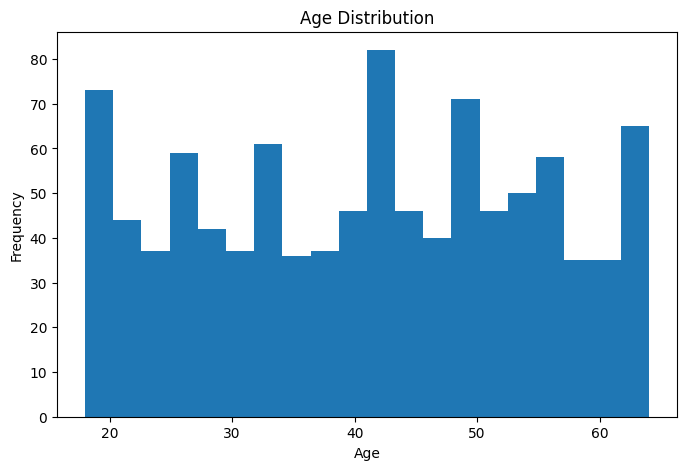

In [11]:
# Age Distribution
plt.figure(figsize=(8,5))
plt.hist(df["age"], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()


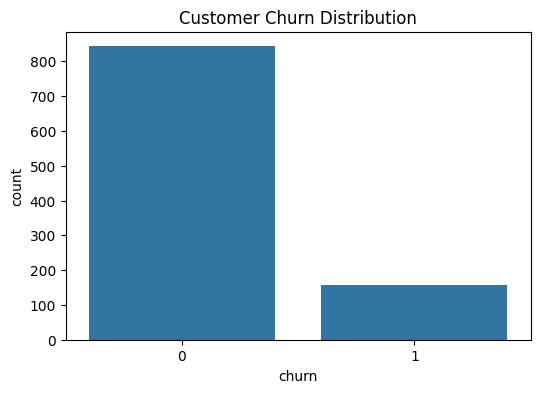

In [12]:
# Churn Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="churn", data=df)
plt.title("Customer Churn Distribution")
plt.show()

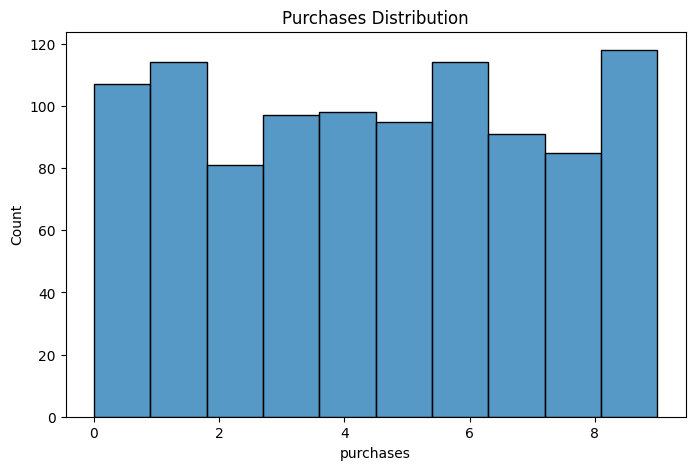

In [13]:
# Purchases Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["purchases"], bins=10)
plt.title("Purchases Distribution")
plt.show()

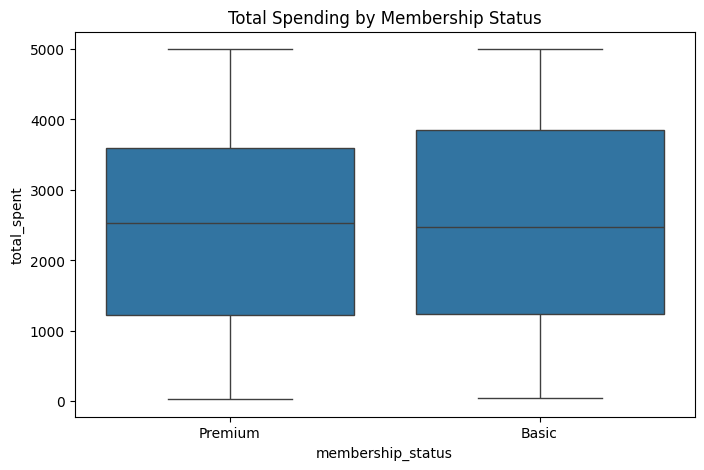

In [14]:
# Total Spending by Membership
plt.figure(figsize=(8,5))
sns.boxplot(
    x="membership_status",
    y="total_spent",
    data=df
)
plt.title("Total Spending by Membership Status")
plt.show()


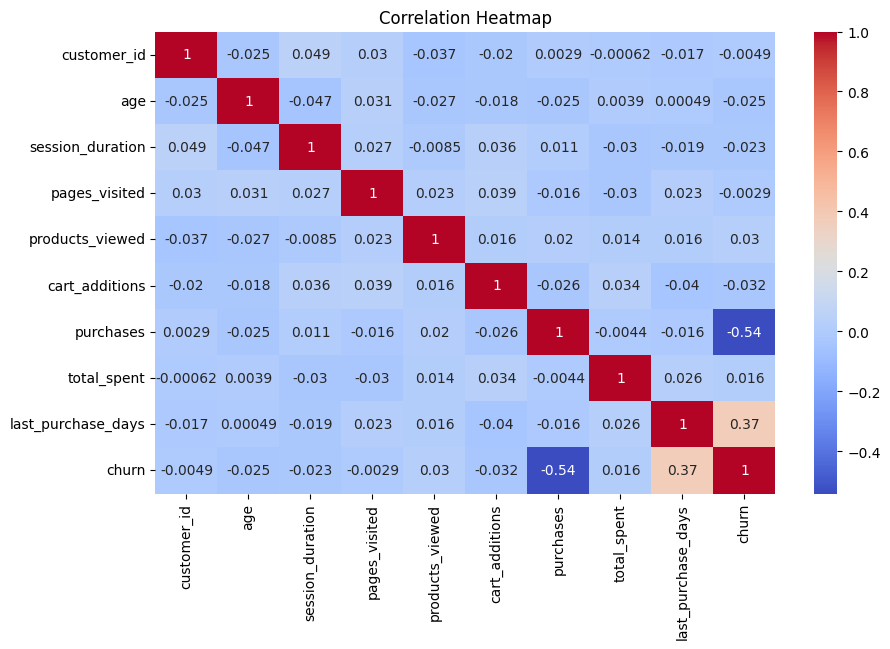

In [15]:
# Correlation Heatmap
plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

## 6. FEATURE ENGINEERING

In [16]:
# Average Purchase Value
df["avg_purchase_value"] = (
    df["total_spent"] / (df["purchases"] + 1)
)

# Engagement Score
df["engagement_score"] = (
    df["session_duration"] +
    df["pages_visited"] +
    df["products_viewed"]
)

# High Value Customer
df["high_value_customer"] = np.where(
    df["total_spent"] > 3000,
    1,
    0
)

# Inactive Customer
df["inactive_customer"] = np.where(
    df["last_purchase_days"] > 90,
    1,
    0
)

# View first 5 rows
df.head()


,customer_id,age,gender,country,device_type,session_duration,pages_visited,products_viewed,cart_additions,purchases,total_spent,last_purchase_days,membership_status,discount_used,churn,avg_purchase_value,engagement_score,high_value_customer,inactive_customer
0,1,56,Male,Nigeria,Desktop,104,30,13,4,5,1455.74,34,Premium,No,0,242.623333,147,0,0
1,2,46,Female,Kenya,Mobile,75,37,13,12,1,1201.37,242,Basic,No,1,600.685000,125,0,1
2,3,32,Female,Nigeria,Tablet,48,25,17,10,3,1075.58,113,Premium,No,0,268.895000,90,0,1
3,4,60,Female,Nigeria,Desktop,32,48,17,3,6,2061.61,318,Premium,Yes,0,294.515714,97,0,1
4,5,25,Male,Nigeria,Desktop,57,27,5,6,7,3523.12,23,Basic,Yes,0,440.390000,89,1,0


##  ENCODE CATEGORICAL VARIABLES

In [17]:
categorical_columns = [
    "gender",
    "country",
    "device_type",
    "membership_status",
    "discount_used"
]

df = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)

df.head()
print("One-Hot Encoding completed")



One-Hot Encoding completed


## FEATURE SCALING

In [18]:
scaler = StandardScaler()

numerical_columns = [
    "age",
    "session_duration",
    "pages_visited",
    "products_viewed",
    "cart_additions",
    "purchases",
    "total_spent",
    "last_purchase_days",
    "avg_purchase_value",
    "engagement_score"
]

df[numerical_columns] = scaler.fit_transform(
    df[numerical_columns]
)

print("Feature engineering completed")


Feature engineering completed


## Train Test Split

In [19]:
X = df.drop(["customer_id", "churn"], axis=1)

y = df["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Model and model fitting

In [20]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


## Model Evalution

In [21]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.99

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       174
           1       1.00      0.96      0.98        26

    accuracy                           0.99       200
   macro avg       1.00      0.98      0.99       200
weighted avg       1.00      0.99      0.99       200



## Confusion Matrix

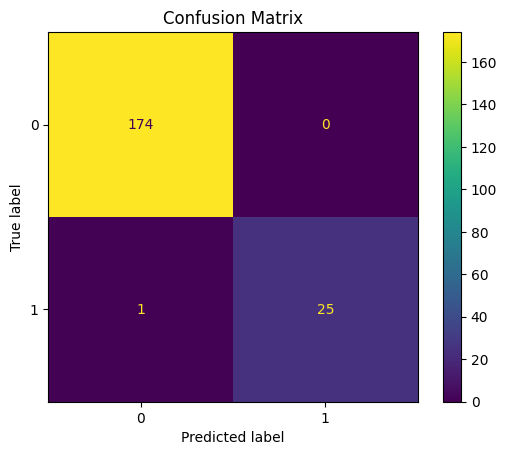

In [22]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Confusion Matrix")
plt.show()


## CROSS VALIDATION

In [23]:
cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=5
)

print("\nCross Validation Scores:")
print(cv_scores)

print("\nAverage CV Score:")
print(cv_scores.mean())




Cross Validation Scores:
[1.    1.    1.    0.995 1.   ]

Average CV Score:
0.999


## FEATURE IMPORTANCE

                      Feature  Importance
5                   purchases    0.384828
7          last_purchase_days    0.258464
8          avg_purchase_value    0.151030
11          inactive_customer    0.042370
6                 total_spent    0.030664
1            session_duration    0.021628
2               pages_visited    0.019740
9            engagement_score    0.019177
3             products_viewed    0.014732
0                         age    0.014104
4              cart_additions    0.013631
18  membership_status_Premium    0.003970
17         device_type_Tablet    0.003932
14            country_Nigeria    0.003825
15       country_South Africa    0.003814
16         device_type_Mobile    0.003350
10        high_value_customer    0.003187
12                gender_Male    0.002876
19          discount_used_Yes    0.002505
13              country_Kenya    0.002172


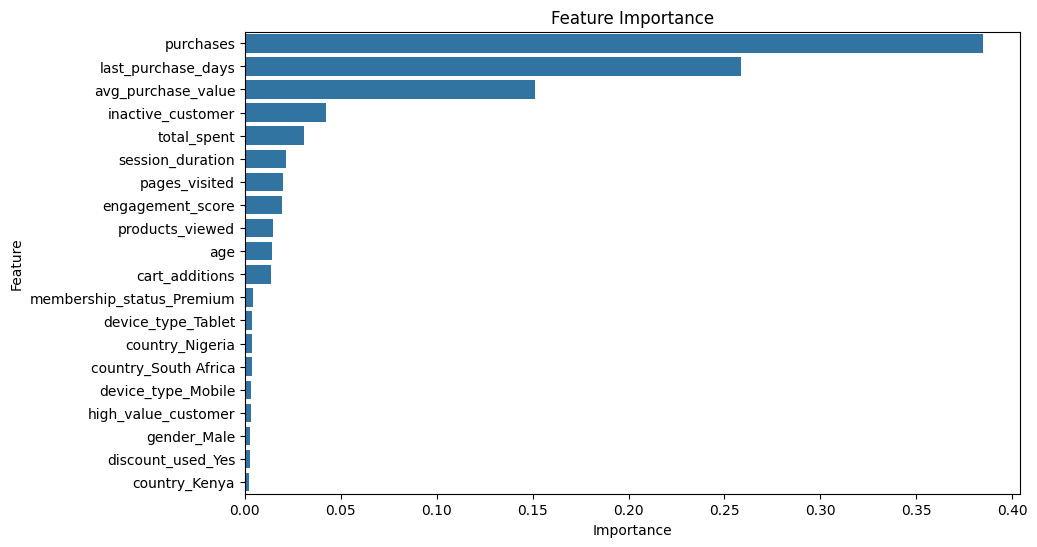

In [24]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)

plt.title("Feature Importance")
plt.show()